# Fraud Detection — Data Science Project

A data science project exploring fraudulent transaction patterns and building machine learning classification models to distinguish fraudulent from legitimate transactions.

## 1. Imports & Setup

Import the libraries used throughout the project for data manipulation, visualization, preprocessing, model training, and evaluation.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


TARGET_COL = "risk_label"

# Models
lr_model = None
dt_model = None
rf_model = None

# Preprocessing
preprocessor = None
scaler = None

# Feature tracking
original_features = None
encoded_features = None

# Class weights
class_weights = None

## 2. Load Dataset

Load the transaction dataset and perform an initial check of its structure, dimensions, and data types.

In [2]:
def load_dataset(file_path):

    df = pd.read_csv(file_path)

    print(">>> Dataset shape:", df.shape)

    print("\n>>> First 5 rows:")
    display(df.head())

    print("\n>>> Dataset Info:")
    df.info()
    return df


df = load_dataset("../data/Credit-Card-Transactions.csv")

>>> Dataset shape: (5300, 15)

>>> First 5 rows:


,transaction_id,customer_id,transaction_hour,account_age_days,previous_chargebacks,merchant_category,transaction_country,device_type,is_international,is_high_risk_merchant,transaction_amount,transaction_velocity_1h,transaction_velocity_24h,avg_transaction_amount_30d,risk_label
0,TXN0000000,CUST00102,13,395.0,0.0,online_services,CA,mobile,1,1,174.76,6.0,5.0,257.88,0
1,TXN0000001,CUST00435,23,NaN,0.0,grocery,US,mobile,0,0,428.85,1.0,1.0,495.38,0
2,TXN0000002,CUST00860,25,1212.0,0.0,grocery,US,mobile,0,0,411.69,0.0,2.0,-640.15,0
3,TXN0000003,CUST00270,21,126.0,0.0,electronics,US,tablet,0,0,128.27,3.0,2.0,546.43,0
4,TXN0000004,CUST00106,6,-705.0,2.0,restaurant,US,mobile,0,0,736.38,2.0,11.0,462.64,0



>>> Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5300 entries, 0 to 5299
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   transaction_id              5300 non-null   object 
 1   customer_id                 5300 non-null   object 
 2   transaction_hour            5300 non-null   int64  
 3   account_age_days            5280 non-null   float64
 4   previous_chargebacks        5285 non-null   float64
 5   merchant_category           5282 non-null   object 
 6   transaction_country         5278 non-null   object 
 7   device_type                 5280 non-null   object 
 8   is_international            5300 non-null   int64  
 9   is_high_risk_merchant       5300 non-null   int64  
 10  transaction_amount          5278 non-null   float64
 11  transaction_velocity_1h     5290 non-null   float64
 12  transaction_velocity_24h    5282 non-null   float64
 13  avg_transactio

## 3. Dataset Overview & Exploratory Data Analysis

Before cleaning the data, we examine its structure, data types, missing values, duplicate records, descriptive statistics, and target distribution to understand the dataset and identify potential data quality issues.

In [3]:
def basic_eda(df, target_col):

    print("\n>>> Dataset Shape:")
    print(df.shape)

    print("\n>>> Column Names:")
    print(df.columns.tolist())

    print("\n>>> Data Types:")
    print(df.dtypes)

    print("\n>>> Missing Values Per Column:")
    print(df.isnull().sum())

    # Save original missing values before any cleaning
    global missing_original
    missing_original = df.isnull().sum().sum()

    print("\n>>> Total Missing Values:")
    print(missing_original)

    print("\n>>> Number of Duplicate Rows:")
    print(df.duplicated().sum())

    print("\n>>> Target Distribution:")
    print(df[target_col].value_counts())

    print("\n>>> Target Distribution (%):")
    print((df[target_col].value_counts(normalize=True) * 100).round(2))

    print("\n>>> Numerical Features Summary:")
    display(df.describe())

    print("\n>>> Categorical Features Summary:")
    display(df.describe(include="object"))

    return df


df = basic_eda(df, TARGET_COL)


>>> Dataset Shape:
(5300, 15)

>>> Column Names:
['transaction_id', 'customer_id', 'transaction_hour', 'account_age_days', 'previous_chargebacks', 'merchant_category', 'transaction_country', 'device_type', 'is_international', 'is_high_risk_merchant', 'transaction_amount', 'transaction_velocity_1h', 'transaction_velocity_24h', 'avg_transaction_amount_30d', 'risk_label']

>>> Data Types:
transaction_id                 object
customer_id                    object
transaction_hour                int64
account_age_days              float64
previous_chargebacks          float64
merchant_category              object
transaction_country            object
device_type                    object
is_international                int64
is_high_risk_merchant           int64
transaction_amount            float64
transaction_velocity_1h       float64
transaction_velocity_24h      float64
avg_transaction_amount_30d    float64
risk_label                      int64
dtype: object

>>> Missing Values Per Co

,transaction_hour,account_age_days,previous_chargebacks,is_international,is_high_risk_merchant,transaction_amount,transaction_velocity_1h,transaction_velocity_24h,avg_transaction_amount_30d,risk_label
count,5300.000000,5280.000000,5285.000000,5300.000000,5300.000000,5278.000000,5290.000000,5282.000000,5278.000000,5300.000000
mean,11.767358,597.459280,0.229707,0.409811,0.303019,462.036129,1.044423,3.768080,463.479504,0.099434
std,6.946431,435.123791,0.628484,0.491845,0.459607,554.276432,1.254416,3.120168,262.455610,0.299272
min,-23.000000,-1024.000000,0.000000,0.000000,0.000000,-810.420000,0.000000,0.000000,-771.760000,0.000000
25%,6.000000,280.000000,0.000000,0.000000,0.000000,162.592500,0.000000,1.000000,296.855000,0.000000
50%,12.000000,502.000000,0.000000,0.000000,0.000000,286.980000,1.000000,3.000000,407.645000,0.000000
75%,18.000000,805.250000,0.000000,1.000000,1.000000,537.287500,2.000000,6.000000,567.265000,0.000000
max,30.000000,3529.000000,4.000000,1.000000,1.000000,7000.000000,9.000000,17.000000,3111.490000,1.000000



>>> Categorical Features Summary:


,transaction_id,customer_id,merchant_category,transaction_country,device_type
count,5300,5300,5282,5278,5280
unique,5000,989,7,5,3
top,TXN0001495,CUST00935,travel,US,mobile
freq,3,14,826,3123,3187


### Target Distribution & Missing Values

Visualize the target class distribution and the missing values identified during the initial dataset assessment.

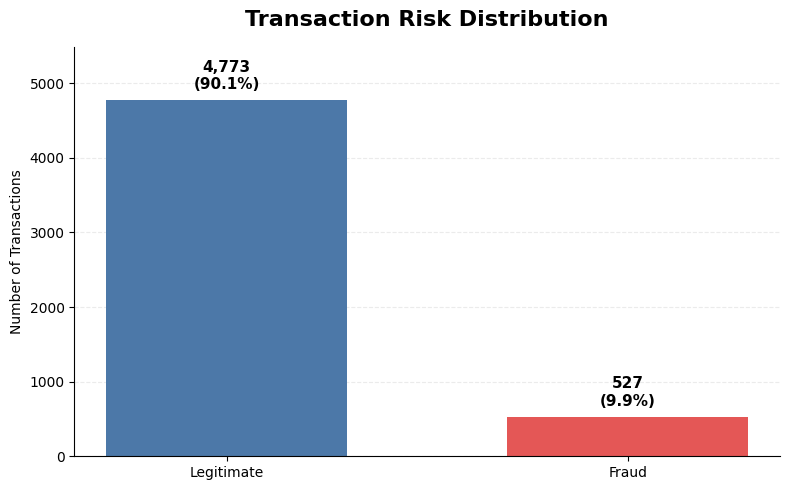

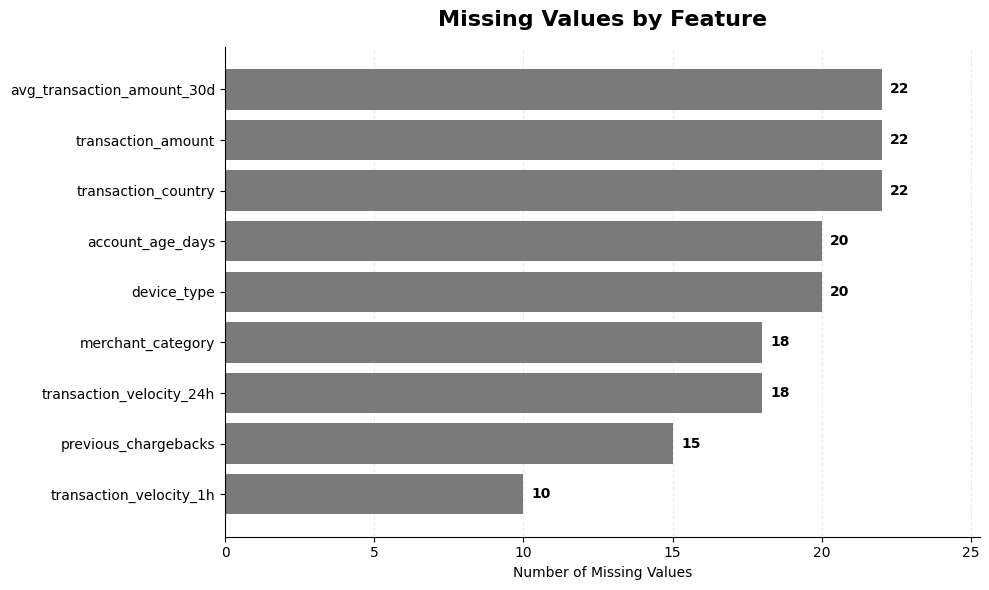

In [4]:
def visualize_target_and_missing_values(df, target_col):

    # Project visualization palette
    legitimate_color = "#4C78A8"
    fraud_color = "#E45756"
    neutral_color = "#7A7A7A"

    # ===============================================================
    # 1. Target Distribution
    # ===============================================================

    counts = df[target_col].value_counts().sort_index()
    total = len(df)

    labels = [
        "Legitimate" if label == 0 else "Fraud"
        for label in counts.index
    ]

    colors = [
        legitimate_color if label == 0 else fraud_color
        for label in counts.index
    ]

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        labels,
        counts.values,
        color=colors,
        width=0.6
    )

    ax.set_title(
        "Transaction Risk Distribution",
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel("")
    ax.set_ylabel("Number of Transactions")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Add count and percentage labels
    for bar, count in zip(bars, counts.values):

        percentage = count / total * 100

        ax.annotate(
            f"{count:,}\n({percentage:.1f}%)",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height()
            ),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    # Light horizontal grid for readability
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)

    ax.set_ylim(
        0,
        max(counts.values) * 1.15
    )

    plt.tight_layout()
    plt.show()

    # ===============================================================
    # 2. Missing Values Distribution
    # ===============================================================

    missing_counts = (
        df.isnull()
        .sum()
        .loc[lambda x: x > 0]
        .sort_values(ascending=True)
    )

    if missing_counts.empty:

        print("No missing values found.")

    else:

        fig, ax = plt.subplots(figsize=(10, 6))

        bars = ax.barh(
            missing_counts.index,
            missing_counts.values,
            color=neutral_color
        )

        ax.set_title(
            "Missing Values by Feature",
            fontsize=16,
            fontweight="bold",
            pad=15
        )

        ax.set_xlabel("Number of Missing Values")
        ax.set_ylabel("")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Add value labels
        for bar, count in zip(
            bars,
            missing_counts.values
        ):

            ax.annotate(
                f"{count}",
                xy=(
                    bar.get_width(),
                    bar.get_y() + bar.get_height() / 2
                ),
                xytext=(6, 0),
                textcoords="offset points",
                va="center",
                fontsize=10,
                fontweight="bold"
            )

        # Light vertical grid for readability
        ax.grid(
            axis="x",
            linestyle="--",
            alpha=0.25
        )

        ax.set_axisbelow(True)

        ax.set_xlim(
            0,
            max(missing_counts.values) * 1.15
        )

        plt.tight_layout()
        plt.show()


visualize_target_and_missing_values(df, TARGET_COL)

## 4. Data Cleaning

Clean the dataset by addressing duplicate records and invalid values while tracking the changes made during the cleaning process.

### Remove Duplicate Records

Identify and remove duplicate transactions while tracking the dataset size and missing values before and after removal.

In [5]:
def remove_duplicates(df):

    global duplicates_before, duplicates_after
    global rows_before_cleaning, rows_after_duplicates
    global missing_after_duplicates

    rows_before_cleaning = len(df)

    duplicates_before = df.duplicated().sum()

    print(f"\n>>> Duplicate rows BEFORE removal: {duplicates_before}")

    df = df.drop_duplicates().reset_index(drop=True)

    rows_after_duplicates = len(df)

    duplicates_after = df.duplicated().sum()

    # Save missing values after duplicate removal
    missing_after_duplicates = df.isnull().sum().sum()

    print(f">>> Rows BEFORE removal: {rows_before_cleaning}")
    print(f">>> Rows AFTER removal:  {rows_after_duplicates}")
    print(f">>> Duplicates removed:  {rows_before_cleaning - rows_after_duplicates}")

    print(
        f">>> Total missing values AFTER duplicate removal: "
        f"{missing_after_duplicates}"
    )

    return df


df = remove_duplicates(df)


>>> Duplicate rows BEFORE removal: 300
>>> Rows BEFORE removal: 5300
>>> Rows AFTER removal:  5000
>>> Duplicates removed:  300
>>> Total missing values AFTER duplicate removal: 158


### Handle Invalid Values

Apply domain-based validation rules to identify impossible or invalid values and convert them to missing values for later imputation.

In [6]:
def handle_invalid_values(df):

    df = df.copy()

    global invalid_before, invalid_after
    global missing_after_invalid

    invalid_count = 0

    # ---------------------------------------------------------------
    # Numeric domain rules
    # ---------------------------------------------------------------

    numeric_non_negative = [
        "transaction_amount",
        "transaction_velocity_1h",
        "transaction_velocity_24h",
        "avg_transaction_amount_30d",
        "account_age_days",
        "previous_chargebacks"
    ]

    for col in numeric_non_negative:

        invalid_mask = df[col].notna() & (df[col] < 0)

        count = invalid_mask.sum()

        if count > 0:
            print(f"\n>>> {col}: {count} invalid negative values")

            invalid_count += count

            df.loc[invalid_mask, col] = np.nan

    # ---------------------------------------------------------------
    # Transaction hour
    # ---------------------------------------------------------------

    invalid_mask = (
        df["transaction_hour"].notna() &
        (
            (df["transaction_hour"] < 0) |
            (df["transaction_hour"] > 23)
        )
    )

    count = invalid_mask.sum()

    if count > 0:
        print(f"\n>>> transaction_hour: {count} invalid values")

        invalid_count += count

        df.loc[invalid_mask, "transaction_hour"] = np.nan

    # ---------------------------------------------------------------
    # Binary features
    # ---------------------------------------------------------------

    binary_columns = [
        "is_international",
        "is_high_risk_merchant"
    ]

    for col in binary_columns:

        invalid_mask = (
            df[col].notna() &
            ~df[col].isin([0, 1])
        )

        count = invalid_mask.sum()

        if count > 0:
            print(f"\n>>> {col}: {count} invalid values")

            invalid_count += count

            df.loc[invalid_mask, col] = np.nan

    # ---------------------------------------------------------------
    # Categorical domain validation
    # ---------------------------------------------------------------

    valid_categories = {
        "merchant_category": [
            "grocery",
            "restaurant",
            "electronics",
            "travel",
            "online_services",
            "fashion",
            "fuel"
        ],

        "device_type": [
            "mobile",
            "desktop",
            "tablet"
        ]
    }

    for col, valid_values in valid_categories.items():

        invalid_mask = (
            df[col].notna() &
            ~df[col].isin(valid_values)
        )

        count = invalid_mask.sum()

        if count > 0:
            print(f"\n>>> {col}: {count} invalid values")

            invalid_count += count

            df.loc[invalid_mask, col] = np.nan

    # ---------------------------------------------------------------
    # Save Before / After values
    # ---------------------------------------------------------------

    invalid_before = invalid_count
    invalid_after = 0

    # Save missing values AFTER invalid → NaN
    missing_after_invalid = df.isnull().sum().sum()

    print("\n" + "-"*70)

    print(
        f">>> Total invalid values BEFORE cleaning: "
        f"{invalid_before}"
    )

    print(
        f">>> Invalid values converted to NaN: "
        f"{invalid_count}"
    )

    print(
        f">>> Invalid values AFTER cleaning: "
        f"{invalid_after}"
    )

    print(
        f">>> Total missing values AFTER invalid → NaN: "
        f"{missing_after_invalid}"
    )

    return df


df = handle_invalid_values(df)


>>> transaction_amount: 9 invalid negative values

>>> avg_transaction_amount_30d: 7 invalid negative values

>>> account_age_days: 10 invalid negative values

>>> transaction_hour: 6 invalid values

----------------------------------------------------------------------
>>> Total invalid values BEFORE cleaning: 32
>>> Invalid values converted to NaN: 32
>>> Invalid values AFTER cleaning: 0
>>> Total missing values AFTER invalid → NaN: 190


### Verify Data Cleaning

Verify that duplicate records and invalid domain values have been handled correctly while confirming that missing values remain available for post-split imputation.

In [7]:
def verify_cleaning(df):

    print("Dataset shape:")
    print(df.shape)

    print("\nDuplicate rows:")
    print(df.duplicated().sum())

    print("\nTotal missing values:")
    print(df.isnull().sum().sum())

    print("\nMissing values by column:")
    print(df.isnull().sum())

    # ---------------------------------------------------------------
    # Domain checks
    # ---------------------------------------------------------------

    print("\nInvalid domain checks:")

    print(
        "Negative transaction amounts:",
        (df["transaction_amount"] < 0).sum()
    )

    print(
        "Negative account ages:",
        (df["account_age_days"] < 0).sum()
    )

    print(
        "Invalid transaction hours:",
        (
            (df["transaction_hour"] < 0) |
            (df["transaction_hour"] > 23)
        ).sum()
    )

    print(
        "Invalid international values:",
        (
            df["is_international"].notna() &
            ~df["is_international"].isin([0, 1])
        ).sum()
    )

    print(
        "Invalid high-risk merchant values:",
        (
            df["is_high_risk_merchant"].notna() &
            ~df["is_high_risk_merchant"].isin([0, 1])
        ).sum()
    )

    # ---------------------------------------------------------------
    # Cleaning status
    # ---------------------------------------------------------------

    print("\nCleaning status:")

    if df.duplicated().sum() == 0:
        print("✓ Duplicate rows removed")
    else:
        print("✗ Duplicate rows still exist")

    if (
        (df["transaction_amount"] < 0).sum() == 0 and
        (df["account_age_days"] < 0).sum() == 0 and
        (
            (df["transaction_hour"] < 0) |
            (df["transaction_hour"] > 23)
        ).sum() == 0
    ):
        print("✓ Invalid numerical domain values handled")
    else:
        print("✗ Invalid numerical values still exist")

    print("✓ Missing values retained for post-split imputation")


verify_cleaning(df)

Dataset shape:
(5000, 15)

Duplicate rows:
0

Total missing values:
190

Missing values by column:
transaction_id                 0
customer_id                    0
transaction_hour               6
account_age_days              28
previous_chargebacks          15
merchant_category             18
transaction_country           21
device_type                   19
is_international               0
is_high_risk_merchant          0
transaction_amount            29
transaction_velocity_1h       10
transaction_velocity_24h      15
avg_transaction_amount_30d    29
risk_label                     0
dtype: int64

Invalid domain checks:
Negative transaction amounts: 0
Negative account ages: 0
Invalid transaction hours: 0
Invalid international values: 0
Invalid high-risk merchant values: 0

Cleaning status:
✓ Duplicate rows removed
✓ Invalid numerical domain values handled
✓ Missing values retained for post-split imputation


## 5. Cleaning Impact

Compare key data-quality indicators before and after the cleaning steps to verify the effect of duplicate removal and invalid-value handling.

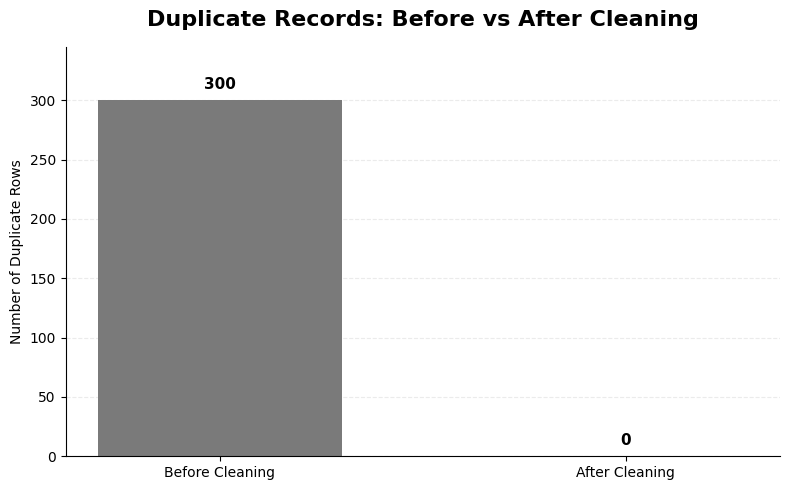

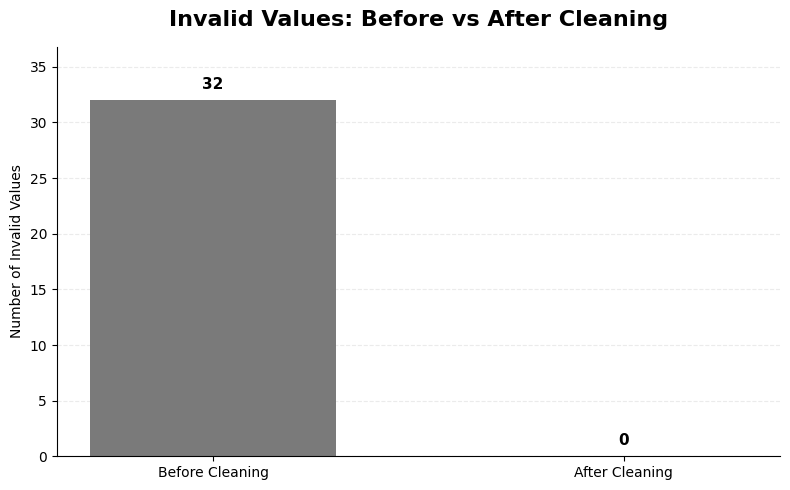

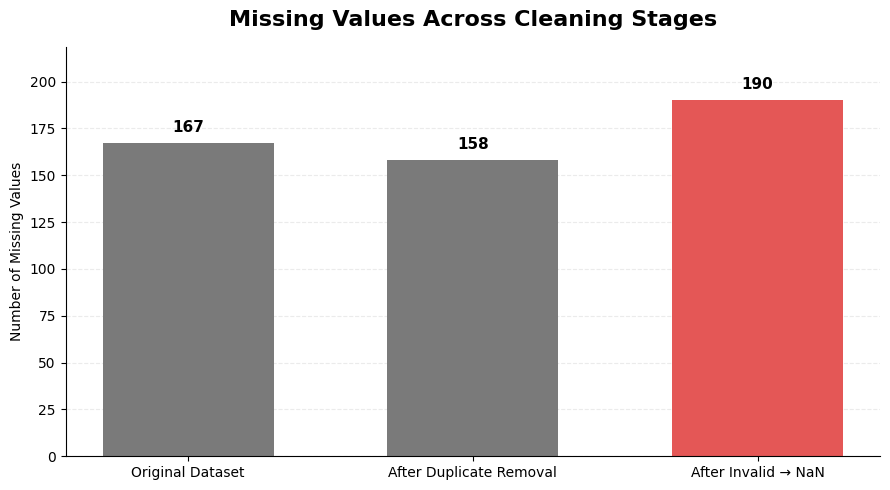

In [8]:
def cleaning_before_after_visualization():

    # Project visualization palette
    before_color = "#7A7A7A"
    after_color = "#4C78A8"
    invalid_color = "#E45756"

    # ===============================================================
    # 1. Duplicate Rows: Before / After
    # ===============================================================

    duplicate_data = pd.DataFrame({
        "Stage": [
            "Before Cleaning",
            "After Cleaning"
        ],
        "Count": [
            duplicates_before,
            duplicates_after
        ]
    })

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        duplicate_data["Stage"],
        duplicate_data["Count"],
        color=[before_color, after_color],
        width=0.6
    )

    ax.set_title(
        "Duplicate Records: Before vs After Cleaning",
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel("")
    ax.set_ylabel("Number of Duplicate Rows")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)

    for bar, value in zip(
        bars,
        duplicate_data["Count"]
    ):
        ax.annotate(
            f"{value:,}",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height()
            ),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    ax.set_ylim(
        0,
        max(duplicate_data["Count"]) * 1.15
        if max(duplicate_data["Count"]) > 0
        else 1
    )

    plt.tight_layout()
    plt.show()

    # ===============================================================
    # 2. Invalid Values: Before / After
    # ===============================================================

    invalid_data = pd.DataFrame({
        "Stage": [
            "Before Cleaning",
            "After Cleaning"
        ],
        "Count": [
            invalid_before,
            invalid_after
        ]
    })

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        invalid_data["Stage"],
        invalid_data["Count"],
        color=[before_color, after_color],
        width=0.6
    )

    ax.set_title(
        "Invalid Values: Before vs After Cleaning",
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel("")
    ax.set_ylabel("Number of Invalid Values")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)

    for bar, value in zip(
        bars,
        invalid_data["Count"]
    ):
        ax.annotate(
            f"{value:,}",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height()
            ),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    ax.set_ylim(
        0,
        max(invalid_data["Count"]) * 1.15
        if max(invalid_data["Count"]) > 0
        else 1
    )

    plt.tight_layout()
    plt.show()

    # ===============================================================
    # 3. Missing Values Across Cleaning Stages
    # ===============================================================

    missing_data = pd.DataFrame({
        "Stage": [
            "Original Dataset",
            "After Duplicate Removal",
            "After Invalid → NaN"
        ],
        "Count": [
            missing_original,
            missing_after_duplicates,
            missing_after_invalid
        ]
    })

    fig, ax = plt.subplots(figsize=(9, 5))

    bars = ax.bar(
        missing_data["Stage"],
        missing_data["Count"],
        color=[
            before_color,
            before_color,
            invalid_color
        ],
        width=0.6
    )

    ax.set_title(
        "Missing Values Across Cleaning Stages",
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel("")
    ax.set_ylabel("Number of Missing Values")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)

    for bar, value in zip(
        bars,
        missing_data["Count"]
    ):
        ax.annotate(
            f"{value:,}",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height()
            ),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    ax.set_ylim(
        0,
        max(missing_data["Count"]) * 1.15
        if max(missing_data["Count"]) > 0
        else 1
    )

    plt.tight_layout()
    plt.show()


cleaning_before_after_visualization()

## 6. Feature Analysis & Fraud Patterns

Analyze the relationship between the available features and the target variable to identify patterns associated with fraudulent transactions and prepare the feature set for modeling.

In [9]:
def analyze_features(df, target_col):

    df = df.copy()

    # ---------------------------------------------------------------
    # 1. Remove Identifier Columns
    # ---------------------------------------------------------------

    columns_to_remove = [
        "transaction_id",
        "customer_id"
    ]

    print("Identifier columns removed:")
    print(columns_to_remove)

    df = df.drop(columns=columns_to_remove)

    # ---------------------------------------------------------------
    # 2. Numerical Feature Analysis
    # ---------------------------------------------------------------

    numerical_cols = df.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()

    numerical_cols.remove(target_col)

    print("\nNumerical features:")
    print(numerical_cols)

    print("\nCorrelation with target:")

    correlation = (
        df[numerical_cols + [target_col]]
        .corr()[target_col]
        .drop(target_col)
        .sort_values(
            key=abs,
            ascending=False
        )
    )

    print(correlation)

    # ---------------------------------------------------------------
    # 3. Categorical / Binary Feature Analysis
    # ---------------------------------------------------------------

    categorical_cols = df.select_dtypes(
        include=["object"]
    ).columns.tolist()

    binary_cols = [
        col for col in df.columns
        if col != target_col
        and set(df[col].dropna().unique()).issubset({0, 1})
    ]

    print("\nCategorical features:")
    print(categorical_cols)

    print("\nBinary features:")
    print(binary_cols)

    # ---------------------------------------------------------------
    # 4. Fraud Rate Analysis
    # ---------------------------------------------------------------

    print("\nFraud rate by categorical features:")

    for col in categorical_cols:

        print(f"\n--- {col} ---")

        fraud_rate = (
            df.groupby(col)[target_col]
            .mean()
            .sort_values(ascending=False)
            * 100
        )

        print(fraud_rate)

    print("\nFraud rate by binary features:")

    for col in binary_cols:

        print(f"\n--- {col} ---")

        fraud_rate = (
            df.groupby(col)[target_col]
            .mean()
            * 100
        )

        print(fraud_rate)

    return df


df = analyze_features(df, TARGET_COL)

Identifier columns removed:
['transaction_id', 'customer_id']

Numerical features:
['transaction_hour', 'account_age_days', 'previous_chargebacks', 'is_international', 'is_high_risk_merchant', 'transaction_amount', 'transaction_velocity_1h', 'transaction_velocity_24h', 'avg_transaction_amount_30d']

Correlation with target:
transaction_velocity_24h      0.492248
transaction_velocity_1h       0.458440
previous_chargebacks          0.456756
transaction_amount            0.301784
is_high_risk_merchant         0.151238
avg_transaction_amount_30d    0.132370
is_international              0.126980
transaction_hour             -0.106276
account_age_days             -0.021401
Name: risk_label, dtype: float64

Categorical features:
['merchant_category', 'transaction_country', 'device_type']

Binary features:
['is_international', 'is_high_risk_merchant']

Fraud rate by categorical features:

--- merchant_category ---
merchant_category
travel             17.322835
online_services    16.597510
gro

### Feature Relationships & Fraud Patterns

Visualize key relationships between the available features and fraudulent transactions identified during the feature analysis.

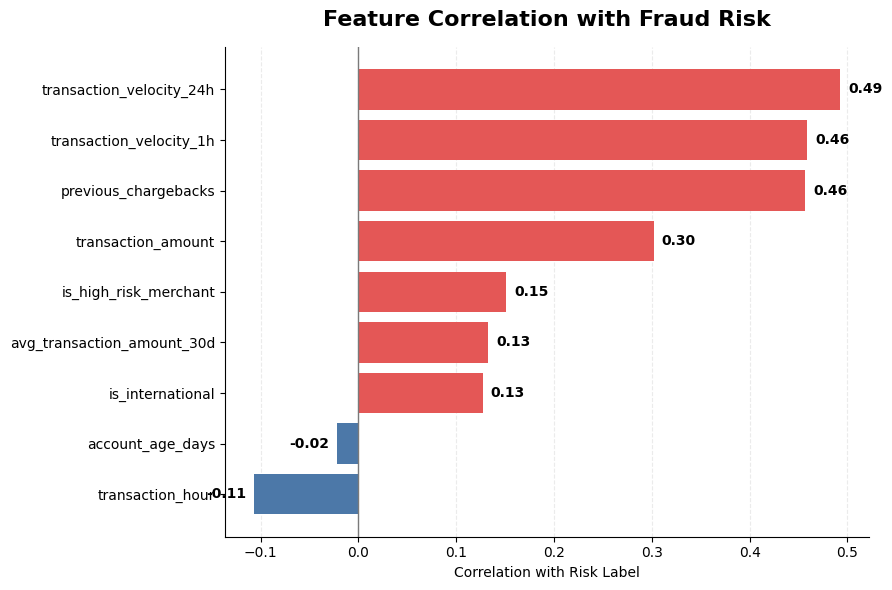

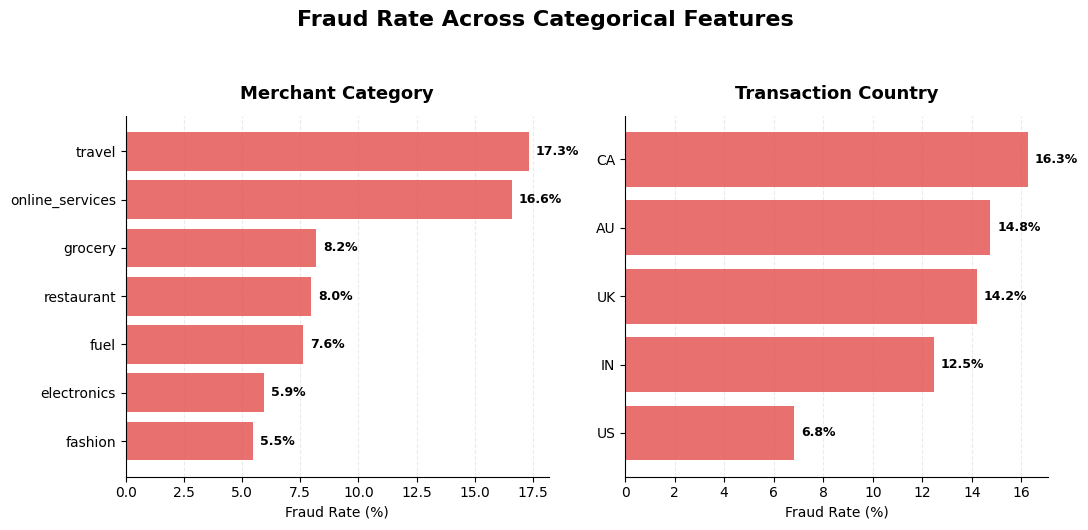

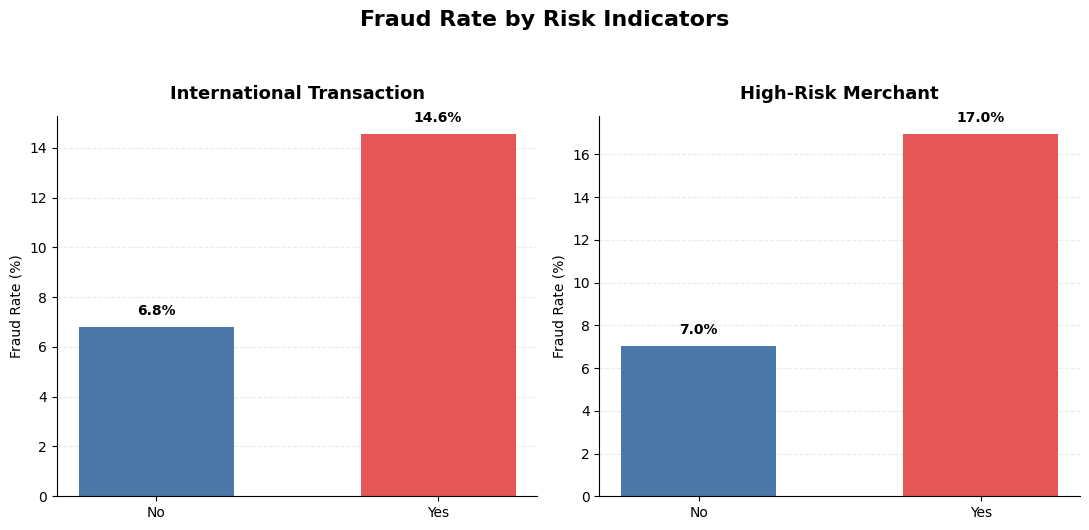

In [10]:
# ===============================================================
# 1. Numerical Feature Correlation with the Target
# ===============================================================

numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numerical_cols.remove(TARGET_COL)

correlation = (
    df[numerical_cols + [TARGET_COL]]
    .corr()[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values()
)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    correlation.index,
    correlation.values,
    color=[
        "#E45756" if value > 0 else "#4C78A8"
        for value in correlation.values
    ]
)

plt.title(
    "Feature Correlation with Fraud Risk",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Correlation with Risk Label")
plt.ylabel("")

plt.axvline(
    0,
    color="#7A7A7A",
    linewidth=1
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.gca().set_axisbelow(True)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

for bar, value in zip(bars, correlation.values):

    plt.annotate(
        f"{value:.2f}",
        xy=(
            value,
            bar.get_y() + bar.get_height() / 2
        ),
        xytext=(
            6 if value >= 0 else -6,
            0
        ),
        textcoords="offset points",
        ha="left" if value >= 0 else "right",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ===============================================================
# 2. Fraud Rate by Categorical Features
# ===============================================================

categorical_cols = [
    "merchant_category",
    "transaction_country"
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5)
)

for ax, col in zip(axes, categorical_cols):

    fraud_rate = (
        df.groupby(col)[TARGET_COL]
        .mean()
        .sort_values(ascending=True)
        * 100
    )

    bars = ax.barh(
        fraud_rate.index,
        fraud_rate.values,
        color="#E45756",
        alpha=0.85
    )

    ax.set_title(
        col.replace("_", " ").title(),
        fontsize=13,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel("Fraud Rate (%)")
    ax.set_ylabel("")

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bar, value in zip(
        bars,
        fraud_rate.values
    ):

        ax.annotate(
            f"{value:.1f}%",
            xy=(
                bar.get_width(),
                bar.get_y() + bar.get_height() / 2
            ),
            xytext=(5, 0),
            textcoords="offset points",
            va="center",
            fontsize=9,
            fontweight="bold"
        )

fig.suptitle(
    "Fraud Rate Across Categorical Features",
    fontsize=16,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()
plt.show()


# ===============================================================
# 3. Fraud Rate by Binary Risk Indicators
# ===============================================================

risk_indicators = {
    "International Transaction": "is_international",
    "High-Risk Merchant": "is_high_risk_merchant"
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5)
)

for ax, (title, col) in zip(
    axes,
    risk_indicators.items()
):

    fraud_rate = (
        df.groupby(col)[TARGET_COL]
        .mean()
        .sort_index()
        * 100
    )

    labels = [
        "No" if value == 0 else "Yes"
        for value in fraud_rate.index
    ]

    bars = ax.bar(
        labels,
        fraud_rate.values,
        color=["#4C78A8", "#E45756"],
        width=0.55
    )

    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel("")
    ax.set_ylabel("Fraud Rate (%)")

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bar, value in zip(
        bars,
        fraud_rate.values
    ):

        ax.annotate(
            f"{value:.1f}%",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height()
            ),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

fig.suptitle(
    "Fraud Rate by Risk Indicators",
    fontsize=16,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()
plt.show()

## 7. Feature Engineering

Create additional features that capture transaction behavior and may provide useful signals for fraud classification.

In [11]:
def engineer_features(df):

    df = df.copy()

    global missing_after_feature_engineering

    # ---------------------------------------------------------------
    # 1. Transaction Amount / 30-Day Average Amount
    # ---------------------------------------------------------------

    df["amount_to_avg_ratio"] = (
        df["transaction_amount"] /
        df["avg_transaction_amount_30d"]
    )

    # ---------------------------------------------------------------
    # 2. Night Transaction
    # ---------------------------------------------------------------

    df["is_night_transaction"] = np.where(
        df["transaction_hour"].isna(),
        np.nan,
        (
            (df["transaction_hour"] >= 0) &
            (df["transaction_hour"] < 6)
        ).astype(int)
    )

    # ---------------------------------------------------------------
    # Display Results
    # ---------------------------------------------------------------

    print("Dataset shape after feature engineering:")
    print(df.shape)

    print("\nEngineered features preview:")

    display(
        df[
            [
                "amount_to_avg_ratio",
                "is_night_transaction"
            ]
        ].head()
    )

    print("\nMissing values in engineered features:")

    print(
        df[
            [
                "amount_to_avg_ratio",
                "is_night_transaction"
            ]
        ].isnull().sum()
    )

    # ---------------------------------------------------------------
    # Save total missing values AFTER feature engineering
    # ---------------------------------------------------------------

    missing_after_feature_engineering = df.isnull().sum().sum()

    print(
        "\nTotal missing values after feature engineering:",
        missing_after_feature_engineering
    )

    return df


df = engineer_features(df)

Dataset shape after feature engineering:
(5000, 15)

Engineered features preview:


,amount_to_avg_ratio,is_night_transaction
0,0.677680,0.0
1,0.865699,0.0
2,NaN,NaN
3,0.234742,0.0
4,1.591691,0.0



Missing values in engineered features:
amount_to_avg_ratio     58
is_night_transaction     6
dtype: int64

Total missing values after feature engineering: 254


## 8. Prepare Features and Target

Separate the input features from the target variable to prepare the dataset for the train/test split and subsequent modeling steps.

In [12]:
def prepare_features_target(df, target_col):

    # ---------------------------------------------------------------
    # Separate features from target
    # ---------------------------------------------------------------

    X = df.drop(columns=[target_col])
    y = df[target_col]

    print("\n>>> Features shape:")
    print(X.shape)

    print("\n>>> Target shape:")
    print(y.shape)

    print("\n>>> Feature columns:")
    print(X.columns.tolist())

    print("\n>>> Target distribution:")
    print(y.value_counts())

    print("\n>>> Target distribution (%):")
    print((y.value_counts(normalize=True) * 100).round(2))

    return X, y


X, y = prepare_features_target(df, TARGET_COL)


>>> Features shape:
(5000, 14)

>>> Target shape:
(5000,)

>>> Feature columns:
['transaction_hour', 'account_age_days', 'previous_chargebacks', 'merchant_category', 'transaction_country', 'device_type', 'is_international', 'is_high_risk_merchant', 'transaction_amount', 'transaction_velocity_1h', 'transaction_velocity_24h', 'avg_transaction_amount_30d', 'amount_to_avg_ratio', 'is_night_transaction']

>>> Target distribution:
risk_label
0    4500
1     500
Name: count, dtype: int64

>>> Target distribution (%):
risk_label
0    90.0
1    10.0
Name: proportion, dtype: float64


## 9. Train / Test Split

Split the dataset into training and testing sets using an 80/20 stratified split to preserve the target class distribution in both sets.

In [13]:
def split_data(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    print("Training set shape:")
    print(X_train.shape)

    print("\nTesting set shape:")
    print(X_test.shape)

    print("\nTraining target distribution:")
    print(y_train.value_counts())

    print("\nTesting target distribution:")
    print(y_test.value_counts())

    print("\nTraining target distribution (%):")
    print((y_train.value_counts(normalize=True) * 100).round(2))

    print("\nTesting target distribution (%):")
    print((y_test.value_counts(normalize=True) * 100).round(2))

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = split_data(X, y)

Training set shape:
(4000, 14)

Testing set shape:
(1000, 14)

Training target distribution:
risk_label
0    3600
1     400
Name: count, dtype: int64

Testing target distribution:
risk_label
0    900
1    100
Name: count, dtype: int64

Training target distribution (%):
risk_label
0    90.0
1    10.0
Name: proportion, dtype: float64

Testing target distribution (%):
risk_label
0    90.0
1    10.0
Name: proportion, dtype: float64


## 10. Missing Value Handling

Handle remaining missing values after the train/test split using statistics learned from the training set only.

Apply median imputation to numerical features and most-frequent imputation to binary and categorical features.

Missing values before imputation:
Training set: 206
Testing set:  48
Total:         254

Missing values after imputation:
Training set: 0
Testing set:  0
Total:        0

Missing values by column after imputation:
transaction_hour              0
account_age_days              0
previous_chargebacks          0
merchant_category             0
transaction_country           0
device_type                   0
is_international              0
is_high_risk_merchant         0
transaction_amount            0
transaction_velocity_1h       0
transaction_velocity_24h      0
avg_transaction_amount_30d    0
amount_to_avg_ratio           0
is_night_transaction          0
dtype: int64

Imputation completed successfully.
Imputers were fitted using training data only.


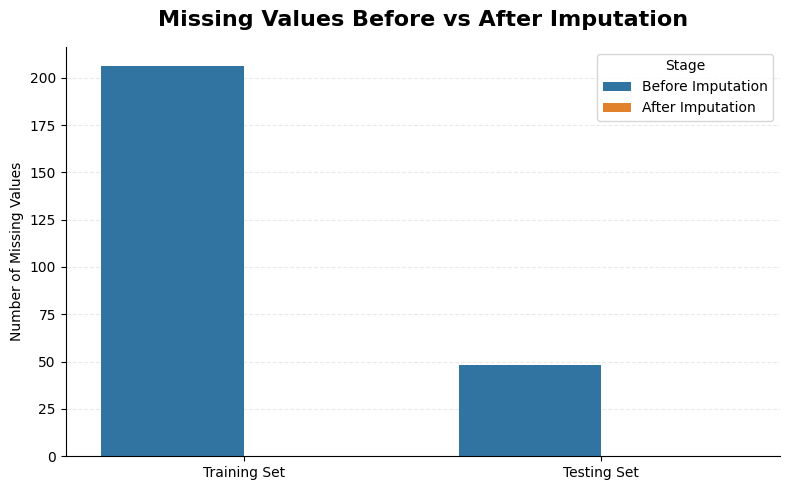

In [14]:
def handle_missing_values_after_split(
    X_train,
    X_test
):

    X_train = X_train.copy()
    X_test = X_test.copy()

    global missing_before_imputation
    global missing_after_imputation

    # ---------------------------------------------------------------
    # Save missing values BEFORE imputation
    # ---------------------------------------------------------------

    missing_before_imputation = {
        "Train": X_train.isnull().sum().sum(),
        "Test": X_test.isnull().sum().sum()
    }

    total_missing_before = (
        missing_before_imputation["Train"] +
        missing_before_imputation["Test"]
    )

    print("Missing values before imputation:")

    print(
        f"Training set: {missing_before_imputation['Train']}"
    )

    print(
        f"Testing set:  {missing_before_imputation['Test']}"
    )

    print(
        f"Total:         {total_missing_before}"
    )

    # ---------------------------------------------------------------
    # Define feature types
    # ---------------------------------------------------------------

    binary_cols = [
        "is_international",
        "is_high_risk_merchant",
        "is_night_transaction"
    ]

    categorical_cols = [
        "merchant_category",
        "transaction_country",
        "device_type"
    ]

    numerical_cols = [
        "transaction_hour",
        "transaction_amount",
        "transaction_velocity_1h",
        "transaction_velocity_24h",
        "avg_transaction_amount_30d",
        "account_age_days",
        "previous_chargebacks",
        "amount_to_avg_ratio"
    ]

    # ---------------------------------------------------------------
    # Numerical → Median
    # ---------------------------------------------------------------

    num_imputer = SimpleImputer(strategy="median")

    X_train[numerical_cols] = num_imputer.fit_transform(
        X_train[numerical_cols]
    )

    X_test[numerical_cols] = num_imputer.transform(
        X_test[numerical_cols]
    )

    # ---------------------------------------------------------------
    # Binary → Most Frequent
    # ---------------------------------------------------------------

    binary_imputer = SimpleImputer(strategy="most_frequent")

    X_train[binary_cols] = binary_imputer.fit_transform(
        X_train[binary_cols]
    )

    X_test[binary_cols] = binary_imputer.transform(
        X_test[binary_cols]
    )

    # ---------------------------------------------------------------
    # Categorical → Most Frequent
    # ---------------------------------------------------------------

    cat_imputer = SimpleImputer(strategy="most_frequent")

    X_train[categorical_cols] = cat_imputer.fit_transform(
        X_train[categorical_cols]
    )

    X_test[categorical_cols] = cat_imputer.transform(
        X_test[categorical_cols]
    )

    # ---------------------------------------------------------------
    # Save missing values AFTER imputation
    # ---------------------------------------------------------------

    missing_after_imputation = {
        "Train": X_train.isnull().sum().sum(),
        "Test": X_test.isnull().sum().sum()
    }

    total_missing_after = (
        missing_after_imputation["Train"] +
        missing_after_imputation["Test"]
    )

    print("\nMissing values after imputation:")

    print(
        f"Training set: {missing_after_imputation['Train']}"
    )

    print(
        f"Testing set:  {missing_after_imputation['Test']}"
    )

    print(
        f"Total:        {total_missing_after}"
    )

    print("\nMissing values by column after imputation:")

    print(X_train.isnull().sum())

    print("\nImputation completed successfully.")
    print("Imputers were fitted using training data only.")

    # ===============================================================
    # Missing Values: Before vs After Imputation
    # ===============================================================

    missing_imputation_data = pd.DataFrame({
        "Dataset": [
            "Training Set",
            "Testing Set"
        ],
        "Before Imputation": [
            missing_before_imputation["Train"],
            missing_before_imputation["Test"]
        ],
        "After Imputation": [
            missing_after_imputation["Train"],
            missing_after_imputation["Test"]
        ]
    })

    missing_imputation_plot = missing_imputation_data.melt(
        id_vars="Dataset",
        var_name="Stage",
        value_name="Missing Values"
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.barplot(
        data=missing_imputation_plot,
        x="Dataset",
        y="Missing Values",
        hue="Stage",
        ax=ax
    )

    ax.set_title(
        "Missing Values Before vs After Imputation",
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel("")
    ax.set_ylabel("Number of Missing Values")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

    return X_train, X_test


X_train, X_test = handle_missing_values_after_split(
    X_train,
    X_test
)

## 11. Outlier Detection & Fraud Rate Analysis

Detect statistical outliers in selected continuous numerical features using IQR bounds calculated from the training data only, and examine their relationship with fraud rates before deciding whether treatment is appropriate.

In [15]:
def handle_outliers_train_test(X_train, X_test, y_train):

    X_train = X_train.copy()
    X_test = X_test.copy()

    global outlier_counts_before
    global outlier_counts_after
    global iqr_bounds
    global outlier_analysis

    # ---------------------------------------------------------------
    # Continuous numerical features
    # ---------------------------------------------------------------

    numerical_cols = [
        "account_age_days",
        "transaction_amount",
        "transaction_velocity_1h",
        "transaction_velocity_24h",
        "avg_transaction_amount_30d",
        "amount_to_avg_ratio"
    ]

    # ---------------------------------------------------------------
    # Calculate IQR using TRAINING DATA ONLY
    # ---------------------------------------------------------------

    iqr_bounds = {}
    outlier_counts_before = {}
    outlier_counts_after = {}
    outlier_analysis = []

    for col in numerical_cols:

        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        iqr_bounds[col] = (lower, upper)

        # -----------------------------------------------------------
        # Identify statistical outliers
        # -----------------------------------------------------------

        outlier_mask = (
            (X_train[col] < lower) |
            (X_train[col] > upper)
        )

        outlier_count = outlier_mask.sum()

        outlier_counts_before[col] = outlier_count

        # -----------------------------------------------------------
        # Compare Fraud Rate
        # -----------------------------------------------------------

        if outlier_count > 0:

            outlier_fraud_rate = (
                y_train[outlier_mask].mean() * 100
            )

            non_outlier_fraud_rate = (
                y_train[~outlier_mask].mean() * 100
            )

            if non_outlier_fraud_rate > 0:
                fraud_rate_lift = (
                    outlier_fraud_rate /
                    non_outlier_fraud_rate
                )
            else:
                fraud_rate_lift = np.nan

        else:

            outlier_fraud_rate = 0

            non_outlier_fraud_rate = (
                y_train.mean() * 100
            )

            fraud_rate_lift = np.nan

        outlier_analysis.append({
            "Feature": col,
            "Outliers": outlier_count,
            "Outlier Fraud Rate (%)": round(
                outlier_fraud_rate,
                2
            ),
            "Non-Outlier Fraud Rate (%)": round(
                non_outlier_fraud_rate,
                2
            ),
            "Fraud Rate Lift": round(
                fraud_rate_lift,
                2
            ) if not np.isnan(fraud_rate_lift) else np.nan
        })

    # ---------------------------------------------------------------
    # Complete analysis
    # ---------------------------------------------------------------

    outlier_analysis = pd.DataFrame(
        outlier_analysis
    )

    display(outlier_analysis)

    # ---------------------------------------------------------------
    # No outlier treatment is applied
    # ---------------------------------------------------------------

    outlier_counts_after = (
        outlier_counts_before.copy()
    )

    return X_train, X_test


X_train, X_test = handle_outliers_train_test(
    X_train,
    X_test,
    y_train
)

,Feature,Outliers,Outlier Fraud Rate (%),Non-Outlier Fraud Rate (%),Fraud Rate Lift
0,account_age_days,135,8.89,10.04,0.89
1,transaction_amount,325,33.54,7.92,4.24
2,transaction_velocity_1h,25,48.00,9.76,4.92
3,transaction_velocity_24h,19,57.89,9.77,5.92
4,avg_transaction_amount_30d,177,19.77,9.55,2.07
5,amount_to_avg_ratio,170,34.71,8.90,3.90


### Outlier Analysis Visualization

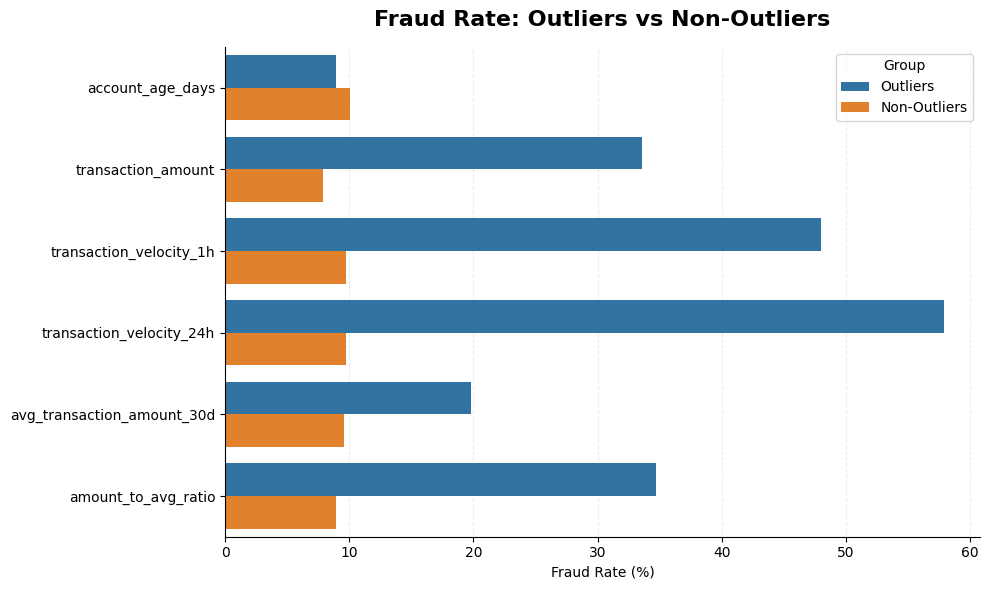

In [16]:
# Fraud rate comparison: Outliers vs Non-Outliers

plot_data = outlier_analysis[
    [
        "Feature",
        "Outlier Fraud Rate (%)",
        "Non-Outlier Fraud Rate (%)"
    ]
].melt(
    id_vars="Feature",
    var_name="Group",
    value_name="Fraud Rate (%)"
)

plot_data["Group"] = plot_data["Group"].replace({
    "Outlier Fraud Rate (%)": "Outliers",
    "Non-Outlier Fraud Rate (%)": "Non-Outliers"
})

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="Fraud Rate (%)",
    y="Feature",
    hue="Group",
    ax=ax
)

ax.set_title(
    "Fraud Rate: Outliers vs Non-Outliers",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Fraud Rate (%)")
ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Outlier Treatment Decision

The detected outliers were retained rather than removed or capped.

The analysis shows that extreme observations in several transaction-related features have different fraud rates compared with non-outlier observations. This suggests that some extreme transaction behaviors may contain useful information for distinguishing fraudulent transactions.

Because these observations may represent meaningful fraud-related patterns rather than data errors, automatic removal or capping could discard potentially useful signals.

Therefore, the identified outliers are retained for model training without additional outlier treatment.

## 12. Feature Preprocessing

Transform the prepared features into a format suitable for machine learning by scaling numerical variables, preserving binary indicators, and one-hot encoding categorical variables.

### Standard Scaling & One-Hot Encoding

In [17]:
def build_preprocessing_pipeline():

    # ---------------------------------------------------------------
    # Numerical features
    # ---------------------------------------------------------------

    numerical_features = [
        "transaction_hour",
        "account_age_days",
        "previous_chargebacks",
        "transaction_amount",
        "transaction_velocity_1h",
        "transaction_velocity_24h",
        "avg_transaction_amount_30d",
        "amount_to_avg_ratio"
    ]

    # ---------------------------------------------------------------
    # Binary features
    # ---------------------------------------------------------------

    binary_features = [
        "is_international",
        "is_high_risk_merchant",
        "is_night_transaction"
    ]

    # ---------------------------------------------------------------
    # Categorical features
    # ---------------------------------------------------------------

    categorical_features = [
        "merchant_category",
        "transaction_country",
        "device_type"
    ]

    # ---------------------------------------------------------------
    # Numerical Pipeline
    # ---------------------------------------------------------------

    numerical_pipeline = Pipeline(
        steps=[
            ("scaler", StandardScaler())
        ]
    )

    # ---------------------------------------------------------------
    # Categorical Pipeline
    # ---------------------------------------------------------------

    categorical_pipeline = Pipeline(
        steps=[
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )

    # ---------------------------------------------------------------
    # Combine all preprocessing steps
    # ---------------------------------------------------------------

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numerical_pipeline,
                numerical_features
            ),
            (
                "binary",
                "passthrough",
                binary_features
            ),
            (
                "cat",
                categorical_pipeline,
                categorical_features
            )
        ],
        remainder="drop"
    )

    return preprocessor


preprocessor = build_preprocessing_pipeline()

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:")
print(X_train_processed.shape)

print("\nProcessed testing shape:")
print(X_test_processed.shape)

Processed training shape:
(4000, 26)

Processed testing shape:
(1000, 26)


## 13. Class Imbalance Handling

Address the class imbalance in the training data by assigning balanced class weights based on the training target distribution.

### Calculate Class Weights

Compute balanced class weights from the training labels only so that the minority fraud class receives greater importance during model training.

In [18]:
def calculate_class_weights(y_train):

    global class_weights

    # ---------------------------------------------------------------
    # Calculate balanced class weights using TRAINING TARGET ONLY
    # ---------------------------------------------------------------

    classes = np.unique(y_train)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )

    class_weights = dict(
        zip(classes, weights)
    )

    # ---------------------------------------------------------------
    # Display class distribution and calculated weights
    # ---------------------------------------------------------------

    class_counts = y_train.value_counts().sort_index()

    print("Training class distribution:")

    for class_label, count in class_counts.items():

        percentage = (
            count / len(y_train)
        ) * 100

        class_name = (
            "Legitimate"
            if class_label == 0
            else "Fraud"
        )

        print(
            f"Class {class_label} ({class_name}): "
            f"{count} samples ({percentage:.2f}%)"
        )

    print("\nCalculated class weights:")

    for class_label, weight in class_weights.items():

        class_name = (
            "Legitimate"
            if class_label == 0
            else "Fraud"
        )

        print(
            f"Class {class_label} ({class_name}): "
            f"{weight:.4f}"
        )

    return class_weights


class_weights = calculate_class_weights(y_train)

Training class distribution:
Class 0 (Legitimate): 3600 samples (90.00%)
Class 1 (Fraud): 400 samples (10.00%)

Calculated class weights:
Class 0 (Legitimate): 0.5556
Class 1 (Fraud): 5.0000


## 14. Model Training

Train and compare three classification models using the same processed training data and class-weighting strategy.

### Logistic Regression

Train a Logistic Regression classifier using the training data with balanced class weights to account for the minority fraud class.

In [19]:
def train_logistic_regression(
    X_train_processed,
    y_train
):

    global lr_model

    # ---------------------------------------------------------------
    # Create Logistic Regression model
    # ---------------------------------------------------------------

    lr_model = LogisticRegression(
        class_weight=class_weights,
        random_state=42,
        max_iter=1000
    )

    # ---------------------------------------------------------------
    # Train model
    # ---------------------------------------------------------------

    lr_model.fit(
        X_train_processed,
        y_train
    )

    print("Logistic Regression training completed.")

    return lr_model


lr_model = train_logistic_regression(
    X_train_processed,
    y_train
)

Logistic Regression training completed.


### Decision Tree

Train a Decision Tree classifier using the same processed training data and class-weighting strategy used for Logistic Regression.

In [20]:
def train_decision_tree(
    X_train_processed,
    y_train
):

    global dt_model

    # ---------------------------------------------------------------
    # Create Decision Tree model
    # ---------------------------------------------------------------

    dt_model = DecisionTreeClassifier(
        class_weight=class_weights,
        random_state=42
    )

    # ---------------------------------------------------------------
    # Train model
    # ---------------------------------------------------------------

    dt_model.fit(
        X_train_processed,
        y_train
    )

    # ---------------------------------------------------------------
    # Training information
    # ---------------------------------------------------------------

    print("Decision Tree training completed.")

    print("\nTree information:")
    print(
        "Number of nodes:",
        dt_model.tree_.node_count
    )

    print(
        "Tree depth:",
        dt_model.get_depth()
    )

    print(
        "Number of leaves:",
        dt_model.get_n_leaves()
    )

    return dt_model


dt_model = train_decision_tree(
    X_train_processed,
    y_train
)

Decision Tree training completed.

Tree information:
Number of nodes: 459
Tree depth: 23
Number of leaves: 230


### Random Forest

Train a Random Forest classifier using the same processed training data and class-weighting strategy as the other models.

In [21]:
def train_random_forest(
    X_train_processed,
    y_train
):

    global rf_model

    # ---------------------------------------------------------------
    # Create Random Forest model
    # ---------------------------------------------------------------

    rf_model = RandomForestClassifier(
        class_weight=class_weights,
        random_state=42
    )

    # ---------------------------------------------------------------
    # Train model
    # ---------------------------------------------------------------

    rf_model.fit(
        X_train_processed,
        y_train
    )

    # ---------------------------------------------------------------
    # Display Forest Information
    # ---------------------------------------------------------------

    print("Random Forest training completed.")

    print("\nRandom Forest information:")
    print(
        "Number of trees:",
        len(rf_model.estimators_)
    )

    print(
        "Number of features used:",
        rf_model.n_features_in_
    )

    return rf_model


rf_model = train_random_forest(
    X_train_processed,
    y_train
)

Random Forest training completed.

Random Forest information:
Number of trees: 100
Number of features used: 26


## 15. Model Evaluation

Evaluate each trained model on the unseen test set using accuracy, precision, recall, F1-score, and ROC-AUC, with particular attention to fraud detection performance.

In [22]:
def evaluate_model(model, model_name, X_test_processed, y_test):

    # ---------------------------------------------------------------
    # Predictions
    # ---------------------------------------------------------------

    y_pred = model.predict(X_test_processed)

    y_proba = model.predict_proba(
        X_test_processed
    )[:, 1]

    # ---------------------------------------------------------------
    # Actual vs Predicted
    # ---------------------------------------------------------------

    comparison_act_pred = pd.DataFrame({
        "Actual": y_test.values,
        "Predicted": y_pred
    })

    comparison_act_pred["Correct"] = (
        comparison_act_pred["Actual"] ==
        comparison_act_pred["Predicted"]
    )

    # ---------------------------------------------------------------
    # Confusion Matrix
    # ---------------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    # ---------------------------------------------------------------
    # Evaluation Metrics
    # ---------------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_proba
    )

    # ---------------------------------------------------------------
    # Classification Report
    # ---------------------------------------------------------------

    print("\n>>> Classification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Legitimate",
                "Fraud"
            ],
            zero_division=0
        )
    )

    # ---------------------------------------------------------------
    # Confusion Matrix
    # ---------------------------------------------------------------

    print("\n>>> Confusion Matrix:")
    print(cm)

    print("\n>>> Confusion Matrix Interpretation:")

    print(
        f"   True Negatives (TN): {cm[0, 0]} "
        f"- Legitimate transactions correctly classified"
    )

    print(
        f"   False Positives (FP): {cm[0, 1]} "
        f"- Legitimate transactions incorrectly classified as Fraud"
    )

    print(
        f"   False Negatives (FN): {cm[1, 0]} "
        f"- Fraud transactions incorrectly classified as Legitimate"
    )

    print(
        f"   True Positives (TP): {cm[1, 1]} "
        f"- Fraud transactions correctly classified"
    )

    # ---------------------------------------------------------------
    # Metrics
    # ---------------------------------------------------------------

    print(f"\n>>> Accuracy : {accuracy:.4f}")
    print(f">>> Precision: {precision:.4f}")
    print(f">>> Recall   : {recall:.4f}")
    print(f">>> F1-score : {f1:.4f}")
    print(f">>> ROC-AUC  : {roc_auc:.4f}")

    # ---------------------------------------------------------------
    # Store Results
    # ---------------------------------------------------------------

    result = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    }

    return {
        "model": model,
        "model_name": model_name,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "cm": cm,
        "comparison": comparison_act_pred,
        "metrics": result
    }

### Logistic Regression Evaluation

Evaluate the Logistic Regression model using its predictions on the test set.

In [23]:
lr_results = evaluate_model(
    lr_model,
    "Logistic Regression",
    X_test_processed,
    y_test
)


>>> Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.88      0.93       900
       Fraud       0.47      0.97      0.63       100

    accuracy                           0.89      1000
   macro avg       0.73      0.92      0.78      1000
weighted avg       0.94      0.89      0.90      1000


>>> Confusion Matrix:
[[790 110]
 [  3  97]]

>>> Confusion Matrix Interpretation:
   True Negatives (TN): 790 - Legitimate transactions correctly classified
   False Positives (FP): 110 - Legitimate transactions incorrectly classified as Fraud
   False Negatives (FN): 3 - Fraud transactions incorrectly classified as Legitimate
   True Positives (TP): 97 - Fraud transactions correctly classified

>>> Accuracy : 0.8870
>>> Precision: 0.4686
>>> Recall   : 0.9700
>>> F1-score : 0.6319
>>> ROC-AUC  : 0.9649


### Decision Tree Evaluation

Evaluate the Decision Tree model using its predictions on the test set.

In [24]:
dt_results = evaluate_model(
    dt_model,
    "Decision Tree",
    X_test_processed,
    y_test
)


>>> Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.96      0.96      0.96       900
       Fraud       0.66      0.63      0.65       100

    accuracy                           0.93      1000
   macro avg       0.81      0.80      0.80      1000
weighted avg       0.93      0.93      0.93      1000


>>> Confusion Matrix:
[[868  32]
 [ 37  63]]

>>> Confusion Matrix Interpretation:
   True Negatives (TN): 868 - Legitimate transactions correctly classified
   False Positives (FP): 32 - Legitimate transactions incorrectly classified as Fraud
   False Negatives (FN): 37 - Fraud transactions incorrectly classified as Legitimate
   True Positives (TP): 63 - Fraud transactions correctly classified

>>> Accuracy : 0.9310
>>> Precision: 0.6632
>>> Recall   : 0.6300
>>> F1-score : 0.6462
>>> ROC-AUC  : 0.7972


### Random Forest Evaluation

Evaluate the Random Forest model using its predictions on the test set.

In [25]:
rf_results = evaluate_model(
    rf_model,
    "Random Forest",
    X_test_processed,
    y_test
)


>>> Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.96      0.99      0.97       900
       Fraud       0.84      0.62      0.71       100

    accuracy                           0.95      1000
   macro avg       0.90      0.80      0.84      1000
weighted avg       0.95      0.95      0.95      1000


>>> Confusion Matrix:
[[888  12]
 [ 38  62]]

>>> Confusion Matrix Interpretation:
   True Negatives (TN): 888 - Legitimate transactions correctly classified
   False Positives (FP): 12 - Legitimate transactions incorrectly classified as Fraud
   False Negatives (FN): 38 - Fraud transactions incorrectly classified as Legitimate
   True Positives (TP): 62 - Fraud transactions correctly classified

>>> Accuracy : 0.9500
>>> Precision: 0.8378
>>> Recall   : 0.6200
>>> F1-score : 0.7126
>>> ROC-AUC  : 0.9774


## 16. Models Comparison

Compare the three trained models using their test-set performance and examine their confusion matrices to identify the most suitable model for fraud classification.

### Performance Comparison

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,88.7%,46.86%,97.0%,63.19%,96.49%
1,Decision Tree,93.1%,66.32%,63.0%,64.62%,79.72%
2,Random Forest,95.0%,83.78%,62.0%,71.26%,97.74%



Models Ranked by F1-score:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,95.0%,83.78%,62.0%,71.26%,97.74%
1,Decision Tree,93.1%,66.32%,63.0%,64.62%,79.72%
2,Logistic Regression,88.7%,46.86%,97.0%,63.19%,96.49%


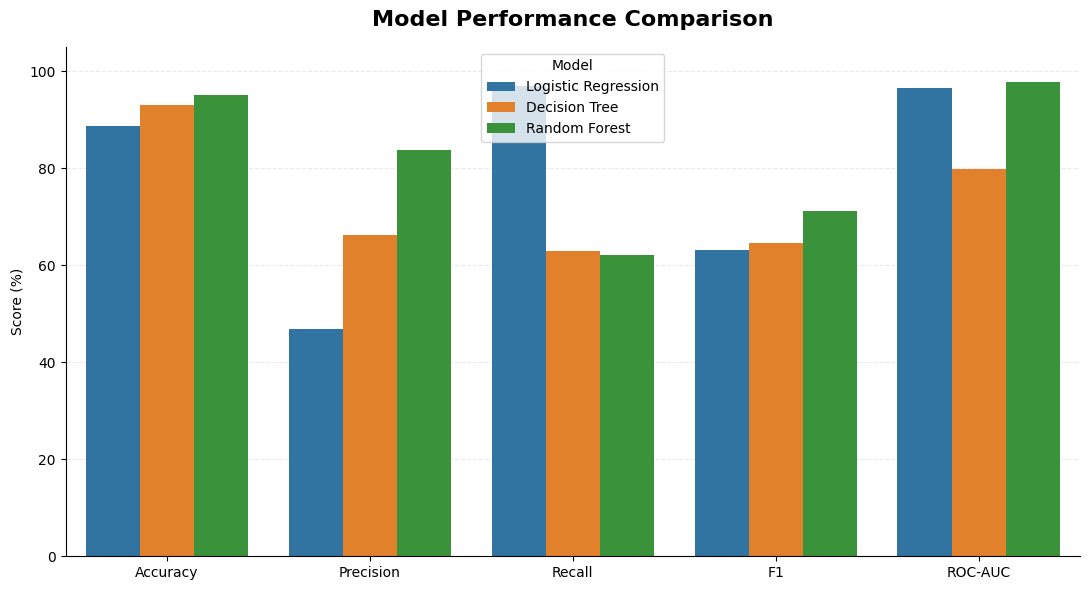

In [26]:
def compare_models(results):

    # ---------------------------------------------------------------
    # Create comparison table
    # ---------------------------------------------------------------

    comparison_df = pd.DataFrame(
        [
            result["metrics"]
            for result in results
        ]
    )

    metrics = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]

    # ---------------------------------------------------------------
    # Create percentage version for display
    # ---------------------------------------------------------------

    display_df = comparison_df.copy()

    display_df[metrics] = (
        display_df[metrics] * 100
    ).round(2)

    display_df[metrics] = (
        display_df[metrics].astype(str) + "%"
    )

    # ---------------------------------------------------------------
    # Rank models by F1-score
    # ---------------------------------------------------------------

    ranked_df = (
        comparison_df
        .sort_values(
            by="F1",
            ascending=False
        )
        .reset_index(drop=True)
    )

    ranked_display_df = ranked_df.copy()

    ranked_display_df[metrics] = (
        ranked_display_df[metrics] * 100
    ).round(2)

    ranked_display_df[metrics] = (
        ranked_display_df[metrics].astype(str) + "%"
    )

    # ---------------------------------------------------------------
    # Display comparison tables
    # ---------------------------------------------------------------

    print("Model Performance Comparison:")

    display(
        display_df
    )

    print("\nModels Ranked by F1-score:")

    display(
        ranked_display_df
    )

    # ---------------------------------------------------------------
    # Performance Visualization
    # ---------------------------------------------------------------

    comparison_plot = comparison_df.melt(
        id_vars="Model",
        value_vars=metrics,
        var_name="Metric",
        value_name="Score"
    )

    # Convert scores to percentages for visualization
    comparison_plot["Score"] = (
        comparison_plot["Score"] * 100
    )

    fig, ax = plt.subplots(
        figsize=(11, 6)
    )

    sns.barplot(
        data=comparison_plot,
        x="Metric",
        y="Score",
        hue="Model",
        ax=ax
    )

    ax.set_title(
        "Model Performance Comparison",
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel("")
    ax.set_ylabel("Score (%)")

    ax.set_ylim(0, 105)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    return comparison_df, ranked_df


model_comparison, ranked_models = compare_models(
    [
        lr_results,
        dt_results,
        rf_results
    ]
)

### Confusion Matrices

Compare the classification errors made by each model, with particular attention to false negatives, where fraudulent transactions are classified as legitimate.

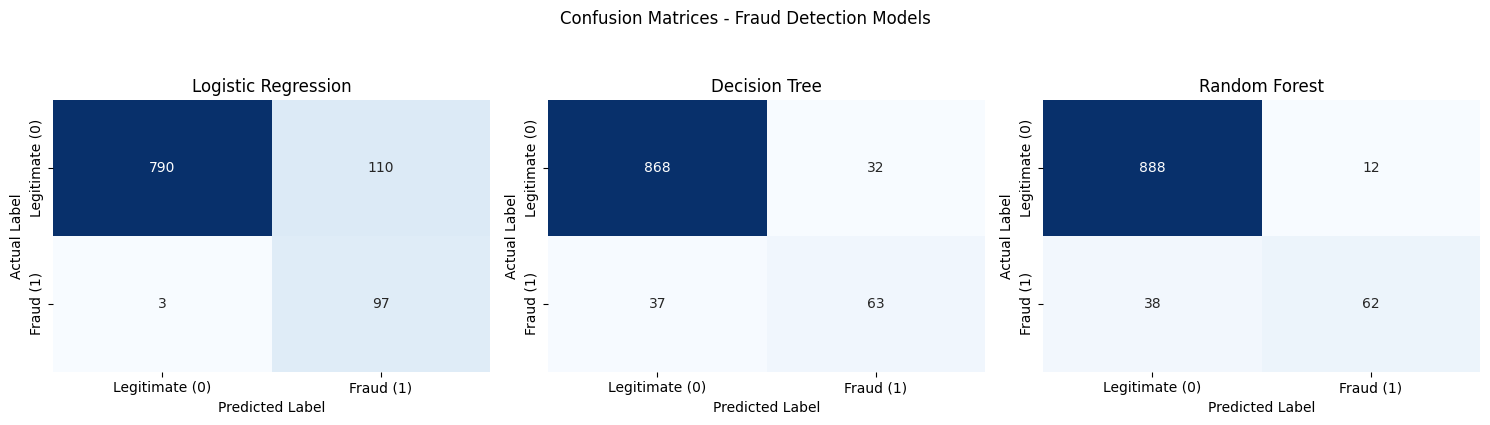


Confusion Matrix Interpretation

Logistic Regression
   TN: 790
   FP: 110  ---> Legitimate transactions incorrectly classified as Fraud
   FN: 3
   TP: 97
   Fraud Detection Rate (Recall): 97.00%
   Fraud Miss Rate (False Negative Rate): 3.00%
   False Positive Rate: 12.22%

Decision Tree
   TN: 868
   FP: 32  ---> Legitimate transactions incorrectly classified as Fraud
   FN: 37
   TP: 63
   Fraud Detection Rate (Recall): 63.00%
   Fraud Miss Rate (False Negative Rate): 37.00%
   False Positive Rate: 3.56%

Random Forest
   TN: 888
   FP: 12  ---> Legitimate transactions incorrectly classified as Fraud
   FN: 38
   TP: 62
   Fraud Detection Rate (Recall): 62.00%
   Fraud Miss Rate (False Negative Rate): 38.00%
   False Positive Rate: 1.33%


In [27]:
def visualize_confusion_matrices(results):

    # ---------------------------------------------------------------
    # Create confusion matrix plots
    # ---------------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        len(results),
        figsize=(15, 4)
    )

    for ax, result in zip(axes, results):

        sns.heatmap(
            result["cm"],
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=ax
        )

        ax.set_title(
            result["model_name"]
        )

        ax.set_xlabel(
            "Predicted Label"
        )

        ax.set_ylabel(
            "Actual Label"
        )

        ax.set_xticklabels([
            "Legitimate (0)",
            "Fraud (1)"
        ])

        ax.set_yticklabels([
            "Legitimate (0)",
            "Fraud (1)"
        ])

    plt.suptitle(
        "Confusion Matrices - Fraud Detection Models",
        y=1.05
    )

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------------
    # Numerical Interpretation
    # ---------------------------------------------------------------

    print("\nConfusion Matrix Interpretation")

    for result in results:

        cm = result["cm"]

        tn = cm[0, 0]
        fp = cm[0, 1]
        fn = cm[1, 0]
        tp = cm[1, 1]

        print(f"\n{result['model_name']}")

        print(f"   TN: {tn}")
        print(f"   FP: {fp}  ---> Legitimate transactions incorrectly classified as Fraud")
        print(f"   FN: {fn}")
        print(f"   TP: {tp}")

        print(
            f"   Fraud Detection Rate (Recall): "
            f"{tp / (tp + fn) * 100:.2f}%"
        )

        print(
            f"   Fraud Miss Rate (False Negative Rate): "
            f"{fn / (tp + fn) * 100:.2f}%"
        )

        print(
            f"   False Positive Rate: "
            f"{fp / (fp + tn) * 100:.2f}%"
        )


visualize_confusion_matrices(
    [
        lr_results,
        dt_results,
        rf_results
    ]
)

## 17. Final Model Selection

Select the final model based on the test-set evaluation results, considering the trade-off between fraud detection performance and false-positive errors.

In [28]:
def final_model_selection(comparison_df, results):

    # ---------------------------------------------------------------
    # Identify best models by key metrics
    # ---------------------------------------------------------------

    best_accuracy = comparison_df.loc[
        comparison_df["Accuracy"].idxmax()
    ]

    best_precision = comparison_df.loc[
        comparison_df["Precision"].idxmax()
    ]

    best_recall = comparison_df.loc[
        comparison_df["Recall"].idxmax()
    ]

    best_f1 = comparison_df.loc[
        comparison_df["F1"].idxmax()
    ]

    best_roc_auc = comparison_df.loc[
        comparison_df["ROC-AUC"].idxmax()
    ]

    # ---------------------------------------------------------------
    # Display best model for each metric
    # ---------------------------------------------------------------

    print("Best Model by Metric:")

    print(
        f"Accuracy : {best_accuracy['Model']} "
        f"({best_accuracy['Accuracy'] * 100:.2f}%)"
    )

    print(
        f"Precision: {best_precision['Model']} "
        f"({best_precision['Precision'] * 100:.2f}%)"
    )

    print(
        f"Recall   : {best_recall['Model']} "
        f"({best_recall['Recall'] * 100:.2f}%)"
    )

    print(
        f"F1-score : {best_f1['Model']} "
        f"({best_f1['F1'] * 100:.2f}%)"
    )

    print(
        f"ROC-AUC  : {best_roc_auc['Model']} "
        f"({best_roc_auc['ROC-AUC'] * 100:.2f}%)"
    )

    # ---------------------------------------------------------------
    # Select final model based on F1-score
    # ---------------------------------------------------------------

    final_model_row = comparison_df.loc[
        comparison_df["F1"].idxmax()
    ]

    final_model_name = final_model_row["Model"]

    final_result = next(
        result
        for result in results
        if result["model_name"] == final_model_name
    )

    # ---------------------------------------------------------------
    # Final decision
    # ---------------------------------------------------------------

    print("\nFinal Model Selection:")
    print(
        f"Selected Model: {final_model_name}"
    )

    print("\nSelection rationale:")

    print(
        f"• Highest F1-score among the three models: "
        f"{final_model_row['F1'] * 100:.2f}%."
    )

    print(
        f"• Accuracy: "
        f"{final_model_row['Accuracy'] * 100:.2f}%."
    )

    print(
        f"• Precision: "
        f"{final_model_row['Precision'] * 100:.2f}%."
    )

    print(
        f"• Recall: "
        f"{final_model_row['Recall'] * 100:.2f}%."
    )

    print(
        f"• ROC-AUC: "
        f"{final_model_row['ROC-AUC'] * 100:.2f}%."
    )

    # ---------------------------------------------------------------
    # Recall trade-off
    # ---------------------------------------------------------------

    if best_recall["Model"] != final_model_name:

        print(
            f"\nTrade-off:"
        )

        print(
            f"{best_recall['Model']} achieved the highest "
            f"Fraud Recall ({best_recall['Recall'] * 100:.2f}%), "
            f"indicating stronger fraud detection coverage."
        )

        print(
            f"However, {final_model_name} provides a stronger "
            f"overall balance according to F1-score."
        )

    print(
        f"\nFinal decision: "
        f"{final_model_name} is selected as the final model "
        f"based on the overall balance between precision and recall."
    )

    return final_model_name, final_result


final_model_name, final_result = final_model_selection(
    model_comparison,
    [
        lr_results,
        dt_results,
        rf_results
    ]
)

Best Model by Metric:
Accuracy : Random Forest (95.00%)
Precision: Random Forest (83.78%)
Recall   : Logistic Regression (97.00%)
F1-score : Random Forest (71.26%)
ROC-AUC  : Random Forest (97.74%)

Final Model Selection:
Selected Model: Random Forest

Selection rationale:
• Highest F1-score among the three models: 71.26%.
• Accuracy: 95.00%.
• Precision: 83.78%.
• Recall: 62.00%.
• ROC-AUC: 97.74%.

Trade-off:
Logistic Regression achieved the highest Fraud Recall (97.00%), indicating stronger fraud detection coverage.
However, Random Forest provides a stronger overall balance according to F1-score.

Final decision: Random Forest is selected as the final model based on the overall balance between precision and recall.


### Random Forest Feature Importance

Analyze the most influential features identified by the Random Forest model after preprocessing and encoding.

,Feature,Importance
0,transaction_velocity_24h,0.2952
1,previous_chargebacks,0.1851
2,transaction_velocity_1h,0.1648
3,transaction_amount,0.0655
4,account_age_days,0.0473
5,amount_to_avg_ratio,0.0468
6,avg_transaction_amount_30d,0.0396
7,transaction_hour,0.0363
8,is_high_risk_merchant,0.0211
9,transaction_country_US,0.0159


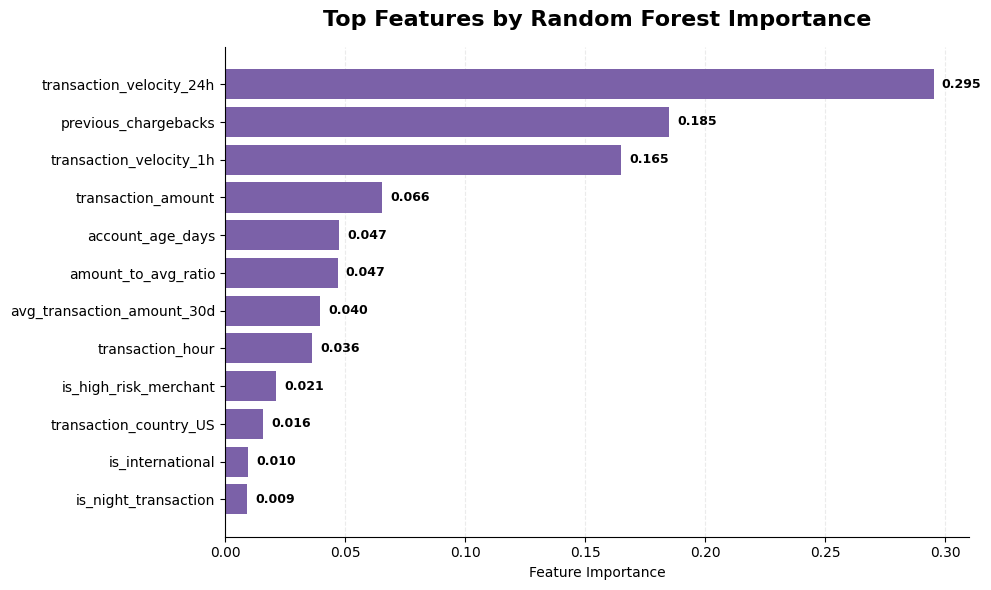

In [29]:
# Random Forest feature importance

feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# ---------------------------------------------------------------
# Clean preprocessing prefixes from feature names
# ---------------------------------------------------------------

feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("binary__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# ---------------------------------------------------------------
# Sort features by importance
# ---------------------------------------------------------------

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------------
# Display top features
# ---------------------------------------------------------------

top_features = feature_importance.head(12)

display(
    top_features.round(4)
)

# ---------------------------------------------------------------
# Feature Importance Visualization
# ---------------------------------------------------------------

plot_data = top_features.sort_values(
    by="Importance",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.barh(
    plot_data["Feature"],
    plot_data["Importance"],
    color="#7B61A8"
)

ax.set_title(
    "Top Features by Random Forest Importance",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---------------------------------------------------------------
# Add importance values
# ---------------------------------------------------------------

for bar, value in zip(
    bars,
    plot_data["Importance"]
):

    ax.annotate(
        f"{value:.3f}",
        xy=(
            value,
            bar.get_y() + bar.get_height() / 2
        ),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## 18. Final Findings & Discussion

### Key Findings

- The dataset is imbalanced, with legitimate transactions representing approximately 90% of the observations and fraud representing approximately 10%.
- Transaction velocity, previous chargebacks, and transaction amount-related features were among the strongest indicators of fraud risk.
- The engineered `amount_to_avg_ratio` feature provided additional predictive information and appeared among the more influential Random Forest features.
- Statistical outliers were retained because extreme transaction behavior may represent meaningful fraud-related patterns rather than data errors.

### Model Performance

Random Forest achieved the strongest overall performance, with the highest Accuracy, Precision, F1-score, and ROC-AUC.

Logistic Regression achieved the highest Fraud Recall (97.00%), detecting more fraudulent transactions but generating substantially more False Positives.

The results therefore highlight a clear trade-off between detecting more fraudulent transactions and reducing false alarms.

### Final Model Selection

Random Forest was selected as the final model because it provided the strongest overall balance between Precision and Recall, reflected by the highest F1-score (71.26%), while also achieving a ROC-AUC of 97.74% and the lowest number of False Positives.

Logistic Regression remains a strong alternative when maximizing fraud detection coverage is the primary objective.

### Limitations & Future Improvements

- The dataset is relatively small and imbalanced, so model performance may not generalize to real-world fraud detection environments.
- The current models use a fixed classification threshold and were not optimized for a specific business cost of False Positives versus False Negatives.
- Future work could explore threshold tuning, cross-validation, hyperparameter optimization, and additional fraud-specific features.
- Model performance should also be validated on new and temporally separated transaction data before real-world deployment.